# Samuel-3 vs synthetic stroke data

Quick check of how well the synthetic stroke data matches the original. Do the proportions of patients in each category match?

## Code setup

In [1]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt

## Load data

### Samuel-3:

In [2]:
df = pd.read_csv('/home/anna/samuel3/data/cleaned_data_anon_teams(in).csv')

In [3]:
df['year'].describe()[['min', 'max']]

min    2020.0
max    2025.0
Name: year, dtype: float64

Relabel stroke teams:

In [4]:
make_teams = False
if make_teams:
    np.random.seed(42)
    
    team_keys = df['stroke_team'].unique()
    np.random.shuffle(team_keys)
    team_values = np.arange(len(team_keys))
    
    team_dict = dict(zip(team_keys, team_values))
    # Save a copy of this:
    pd.Series(team_dict).to_csv('./anon/teamlookup.csv')
else:
    team_dict = pd.read_csv('./anon/teamlookup.csv', index_col=0).squeeze().to_dict()

In [5]:
# Apply map to df:
df['stroke_team'] = df['stroke_team'].map(team_dict).astype(str)

One-hot-encode the stroke teams:

In [6]:
df = pd.concat((df, pd.get_dummies(df['stroke_team']).astype(int)), axis='columns')
df = df.drop('stroke_team', axis='columns')

Remove large arrival times:

In [7]:
df = df[df['onset_to_arrival_time'] < 60*4]

Remove large arrival-to-scan times:

In [8]:
df['arrival_to_scan_time'].quantile(np.clip(np.arange(0.75, 1.01, 0.05), a_min=0.0, a_max=1.0))

0.75        46.0
0.80        57.0
0.85        75.0
0.90       115.0
0.95       216.0
1.00    132485.0
Name: arrival_to_scan_time, dtype: float64

In [9]:
df = df[df['arrival_to_scan_time'] < 4*60]

Make new column for discharge disability mRS<=x for x from 0 to 5 (note that mRS<=6 is always true):

In [10]:
for x in range(6):
    df[f'discharge_mrs{x}'] = (df['discharge_disability'] == x).astype(int)
    df[f'discharge_mrsleq{x}'] = (df['discharge_disability'] <= x).astype(int)
# for x in range(5):
#     df[f'prior_mrsleq{x}'] = (df['prior_disability'] <= x).astype(int)

Convert mRS to utility (use the Dijkland values):

In [12]:
util_scores = dict(zip(range(7), [0.95, 0.93, 0.83, 0.62, 0.42, 0.11, 0.0]))

In [13]:
df['prior_util'] = df['prior_disability'].map(util_scores)
df['discharge_util'] = df['discharge_disability'].map(util_scores)

Convert stroke severity to mild/moderate/severe (cutoffs based on SHAP values from Pearn et al. 2023):

In [14]:
df['stroke_severity_mild'] = (df['stroke_severity'] < 5).astype(int)
df['stroke_severity_moderate'] = ((df['stroke_severity'] >= 5) & (df['stroke_severity'] <= 30)).astype(int)
df['stroke_severity_severe'] = (df['stroke_severity'] > 30).astype(int)

Convert age to over/under 80:

In [15]:
df['age_80plus'] = (df['age'] > 80).astype(int)

Pick out stroke team columns:

In [25]:
stroke_teams = df.columns[df.columns.str.isnumeric()]

In [26]:
stroke_teams

Index(['0', '1', '10', '100', '101', '102', '103', '104', '105', '106',
       ...
       '90', '91', '92', '93', '94', '95', '96', '97', '98', '99'],
      dtype='object', length=116)

### Synthetic data

Rename columns to match the Samuel-3 names:

In [16]:
col_name={
    "Mild Stroke":"stroke_severity_mild",
    "Moderate Stroke":"stroke_severity_moderate",
    "Severe Stroke":"stroke_severity_severe",
    "Age":"age_80plus",
    "Utility":"prior_util",
    "AF_patients":"atrial_fibrillation",
    "AF_patients_on_anticoagulants":"afib_anticoagulant",
    "Onset_during_sleep":"onset_during_sleep",
    "Precise_onset_known":"precise_onset_known",
    "Arrival to scan time":"arrival_to_scan_time"}
df_synth=pd.read_csv("final_results_11_08.csv", index_col=0)
df_synth=df_synth.rename(columns=col_name)

Assign outcomes based on probability (note, not stochastic like usual):

In [49]:
df_synth['discharge_mrsleq2_prob'] = df_synth['discharge_mrsleq2'].copy()
df_synth['discharge_mrsleq2'] = (df_synth['discharge_mrsleq2_prob'] > 0.5).astype(int)

### Effect sizes

Causal effects from linear regression on Samuel-3 data.

In [19]:
df_effects=pd.read_csv("effects_linreg_allpatients.csv", index_col=0)
# df_effects=df_effects.fillna(0)
# df_effects

In [20]:
df_effects = df_effects.drop('discharge_util', axis='columns')
df_effects = df_effects.drop('discharge_util', axis='rows')

In [21]:
df_effects

,precise_onset_known,afib_anticoagulant,prior_util,arrival_to_scan_time,thrombolysis,discharge_mrsleq2
onset_during_sleep,-0.65821,NaN,NaN,NaN,-0.12155,NaN
precise_onset_known,NaN,NaN,NaN,NaN,0.13737,NaN
atrial_fibrillation,NaN,0.63438,NaN,NaN,NaN,-0.02420
afib_anticoagulant,NaN,NaN,NaN,NaN,-0.29834,NaN
prior_util,NaN,NaN,NaN,NaN,0.32325,0.77955
...,...,...,...,...,...,...
107,NaN,NaN,NaN,-15.34494,-0.07294,0.02324
108,NaN,NaN,NaN,-6.27410,0.03744,-0.03315
thrombolysis,NaN,NaN,NaN,NaN,NaN,0.10451
discharge_mrsleq2,NaN,NaN,NaN,NaN,NaN,NaN


## Functions

To convert two columns of the dataframe into a grid:

In [22]:
def grid_overlap_two(df, col1, col2):
    """
    Convert two df column counts into a grid.

    df should contain two columns called col1 and col2.
    This finds how many rows of data have each combined values
    of col1 and col2.
    """
    # How many people are in each combo of values?
    df_g = df[[col1, col2]].value_counts()
    df_g.name = 'counts'
    
    # Convert counts to proportion of all patients:
    df_g = df_g / df_g.sum()
    
    # Convert list to grid:
    df_g = df_g.reset_index()
    df_g = df_g.pivot(columns=col1, index=col2, values='counts')
    return df_g

To plot two grids side-by-side:

In [56]:
def compare_data(df_sam, df_synth, parent, child, savename=''):
    # Make grids:
    grid_sam = grid_overlap_two(df_sam, parent, child)
    grid_synth = grid_overlap_two(df_synth, parent, child)

    # Set up shared colour limits:
    vmin = min(grid_sam.min().min(), grid_synth.min().min())
    vmax = max(grid_sam.max().max(), grid_synth.max().max())
    
    fig, axs = plt.subplots(1, 3, figsize=(12, 5),
                            gridspec_kw={'width_ratios': [2, 2, 0.1]})

    for i, df_g in enumerate([grid_sam, grid_synth]):
        ax = axs[i]
        # Heatmap:
        df_g = df_g[sorted(df_g.columns)]
        df_g = df_g.sort_index()
        c = ax.imshow(df_g, cmap='Blues', origin='lower',
                      vmin=vmin, vmax=vmax)
        # Colour bar:
        if i == 1:
            plt.colorbar(c, cax=axs[-1], label='Proportion of patients')
        # Labels on grid:
        for r, row in enumerate(df_g.index):
            for c, col in enumerate(df_g.columns):
                v = df_g.loc[row, col]
                v = 0.0 if np.isnan(v) else v
                ax.annotate(f'{v:.1%}', xy=(c, r), ha='center', va='center')

        # Axis setup:
        ax.set_yticks(range(len(df_g.index)), labels=df_g.index)
        ax.set_xticks(range(len(df_g.columns)), labels=df_g.columns)
        ax.set_ylabel(child)
        ax.set_xlabel(parent)

    axs[0].set_title('SAMueL-3')
    axs[1].set_title('Synthetic')

    if len(savename) > 0:
        plt.savefig(savename, bbox_inches='tight')
    plt.show()

## Compare data

Compare each pair of features that have a causal link, except for stroke team because there are too many.

precise_onset_known: ['onset_during_sleep']


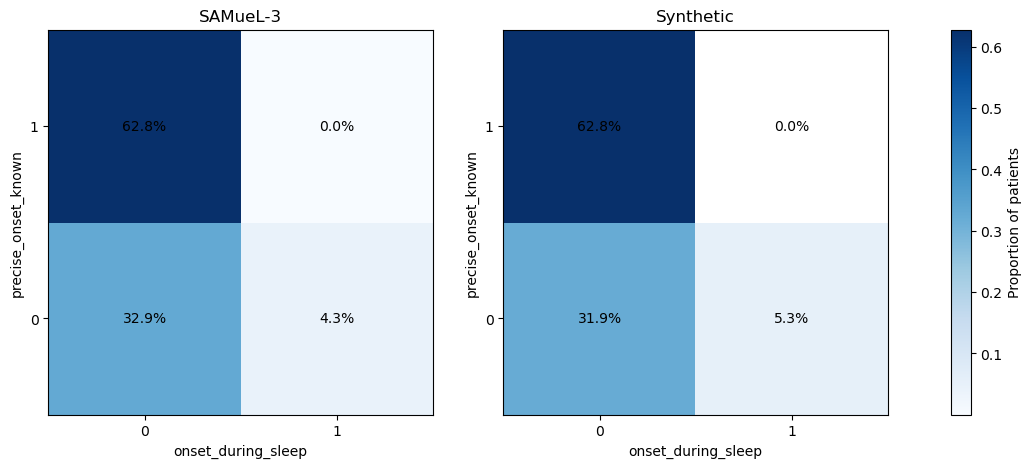

afib_anticoagulant: ['atrial_fibrillation']


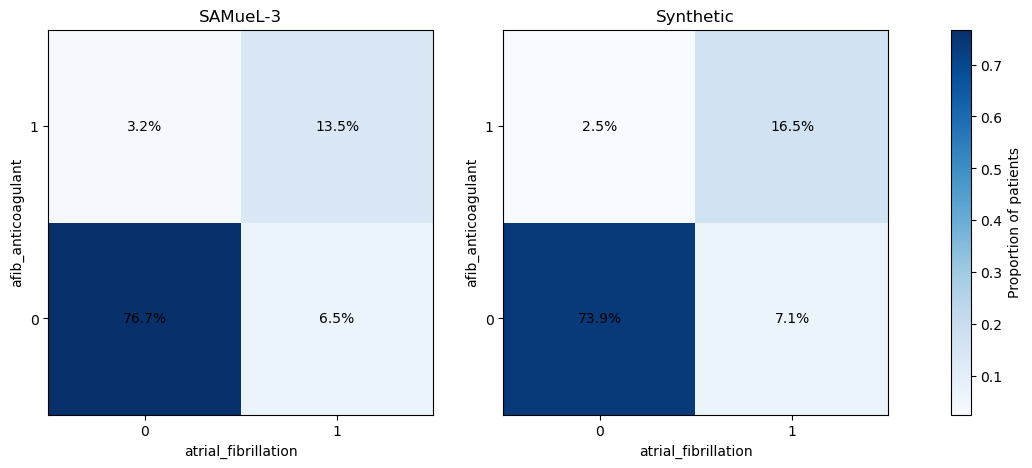

prior_util: ['age_80plus']


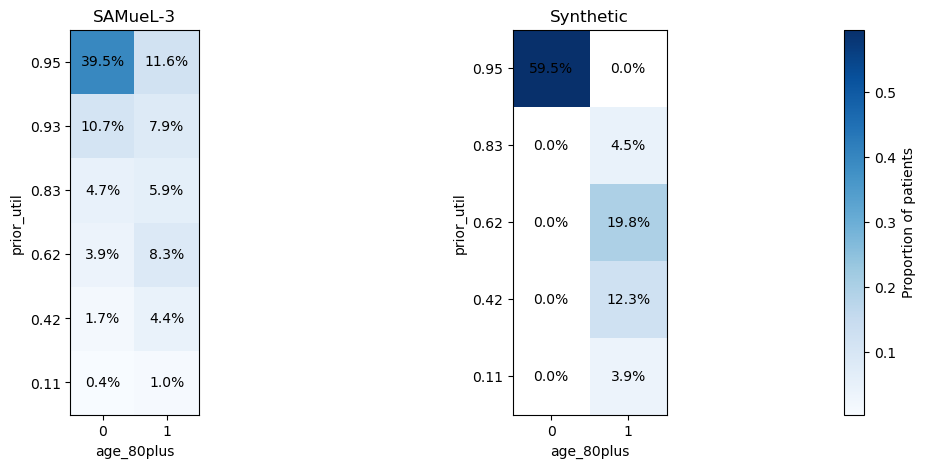

arrival_to_scan_time: ['2', '3', '5', '6', '7', '8', '9', '11', '12', '13', '14', '18', '20', '21', '24', '25', '28', '29', '31', '32', '33', '34', '36', '38', '39', '40', '42', '43', '45', '47', '48', '49', '51', '55', '56', '58', '60', '61', '62', '65', '66', '68', '70', '71', '72', '73', '74', '76', '77', '78', '80', '82', '83', '85', '87', '93', '94', '95', '98', '99', '100', '103', '104', '106', '107', '108']
thrombolysis: ['onset_during_sleep', 'precise_onset_known', 'afib_anticoagulant', 'prior_util', 'age_80plus', 'stroke_severity_mild', 'stroke_severity_moderate', 'stroke_severity_severe', 'arrival_to_scan_time', '2', '3', '5', '6', '7', '8', '9', '11', '12', '13', '14', '18', '20', '21', '24', '25', '28', '29', '31', '32', '33', '34', '36', '38', '39', '40', '42', '43', '45', '47', '48', '49', '51', '55', '56', '58', '60', '61', '62', '65', '66', '68', '70', '71', '72', '73', '74', '76', '77', '78', '80', '82', '83', '85', '87', '93', '94', '95', '98', '99', '100', '103', '10

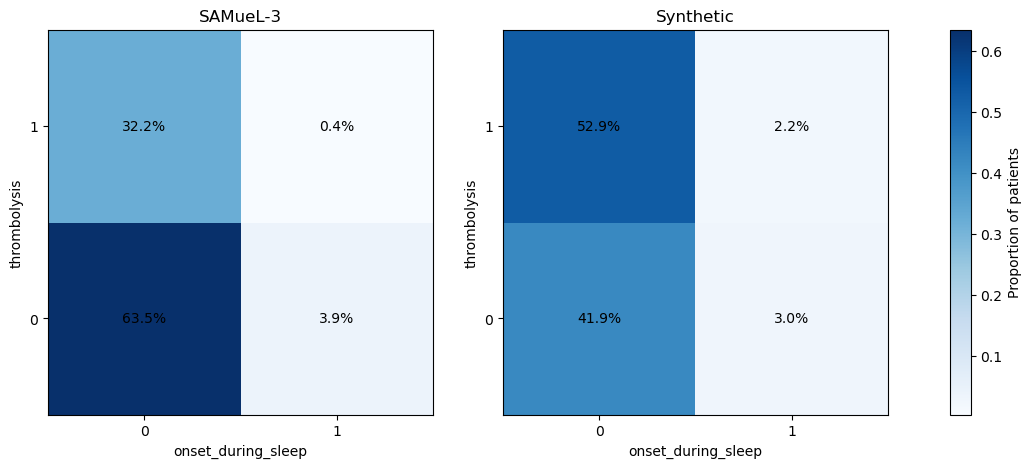

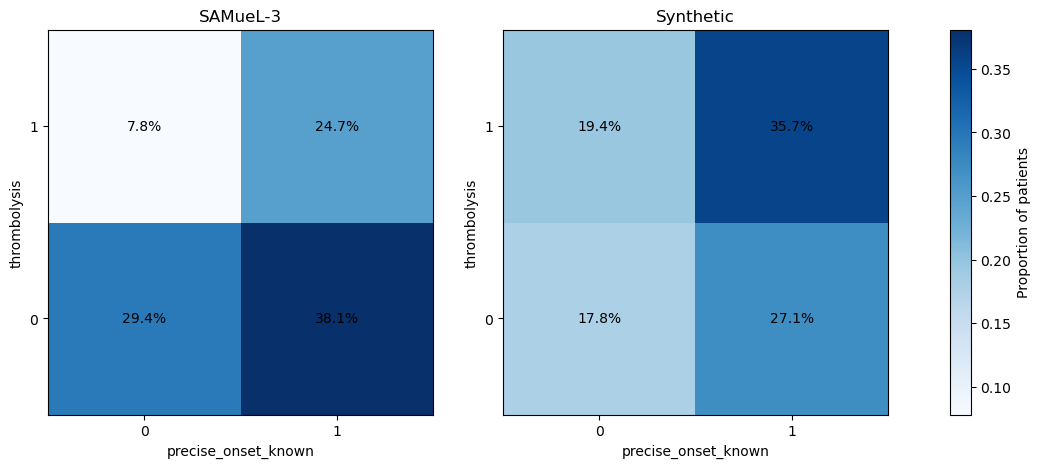

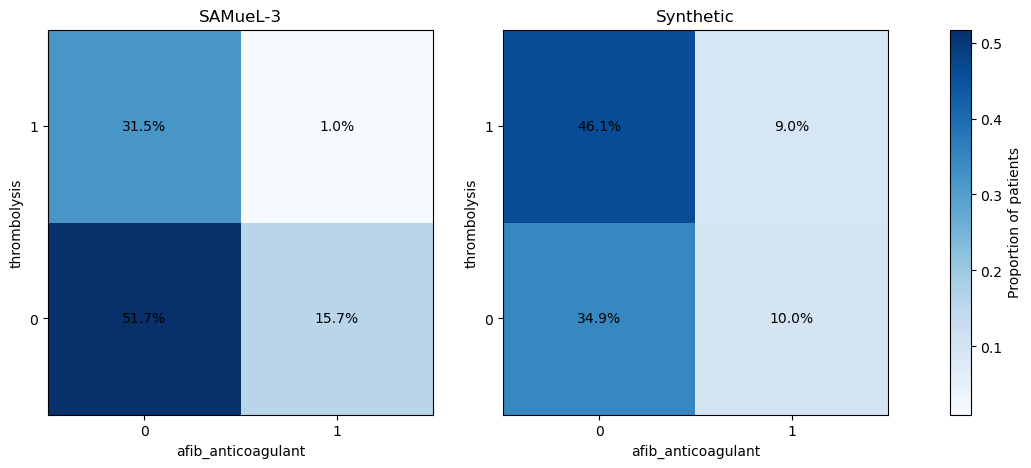

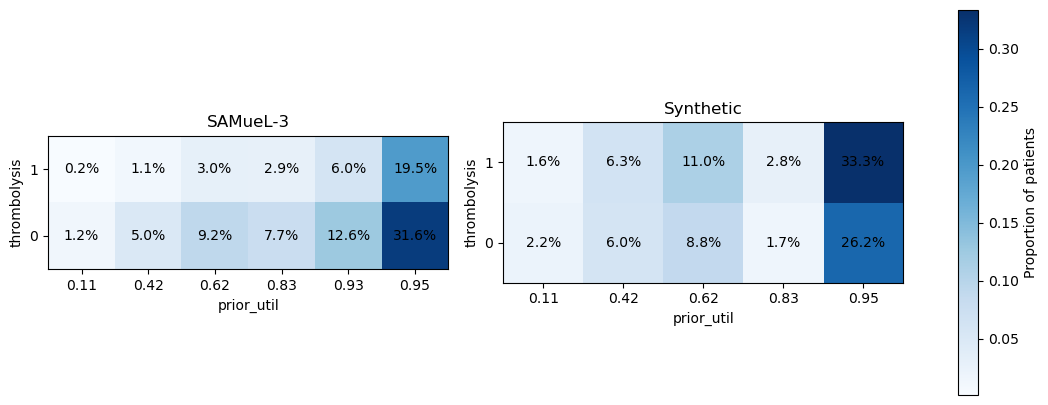

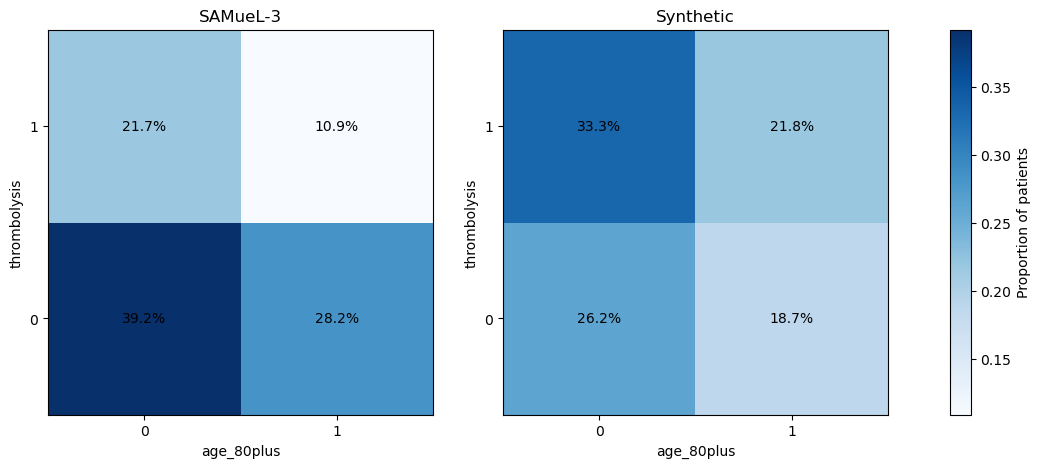

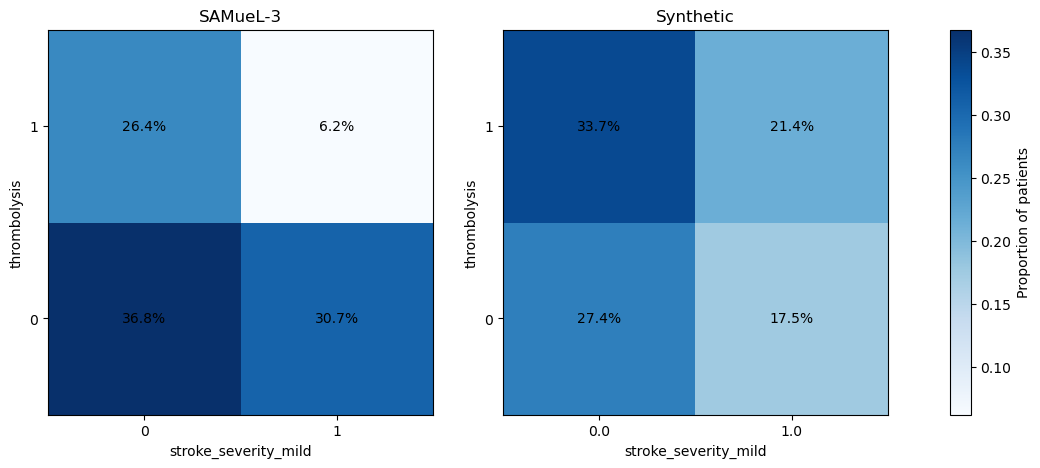

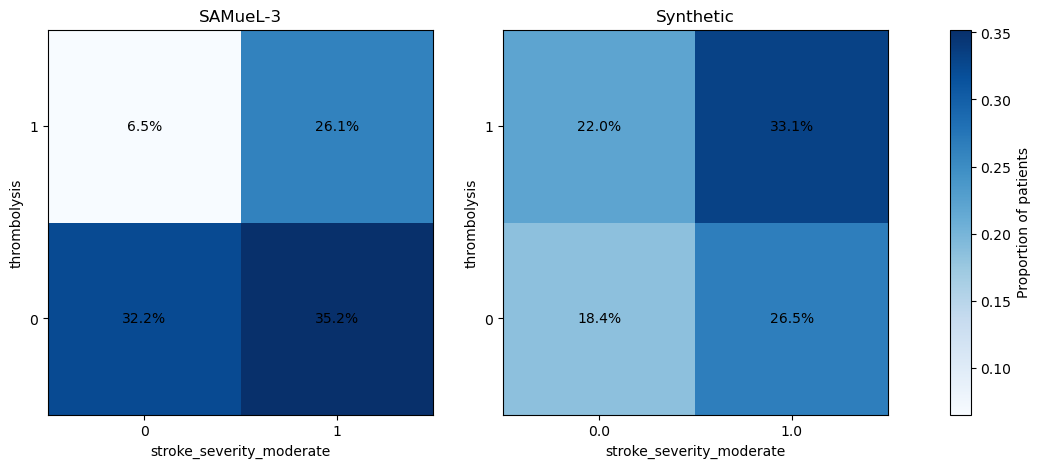

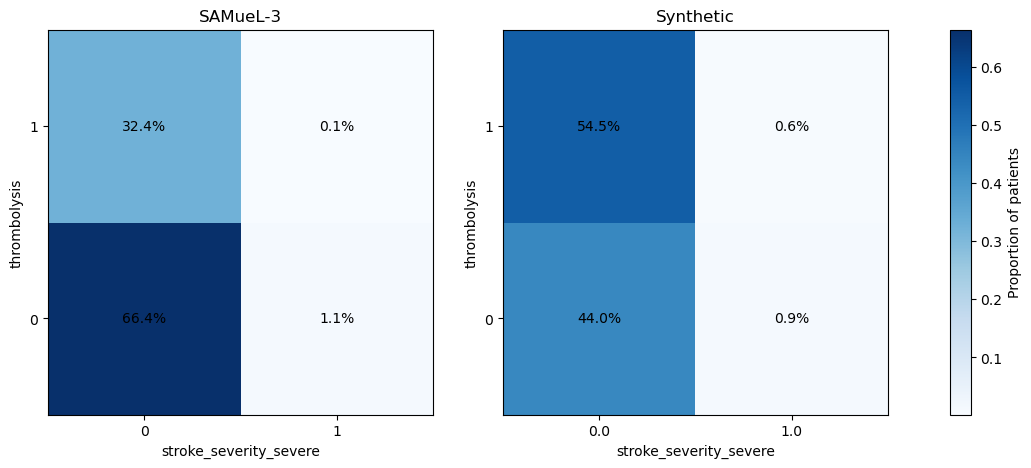

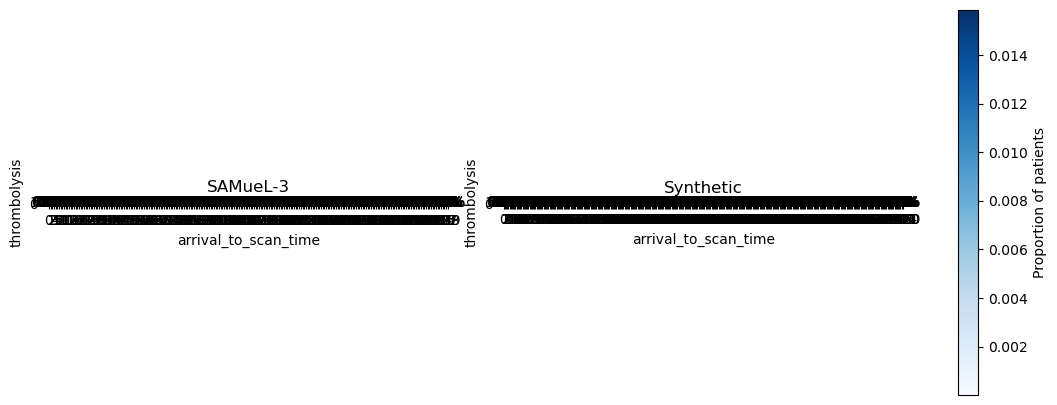

discharge_mrsleq2: ['atrial_fibrillation', 'prior_util', 'age_80plus', 'stroke_severity_mild', 'stroke_severity_moderate', 'stroke_severity_severe', '2', '3', '5', '6', '7', '8', '9', '11', '12', '13', '14', '18', '20', '21', '24', '25', '28', '29', '31', '32', '33', '34', '36', '38', '39', '40', '42', '43', '45', '47', '48', '49', '51', '55', '56', '58', '60', '61', '62', '65', '66', '68', '70', '71', '72', '73', '74', '76', '77', '78', '80', '82', '83', '85', '87', '93', '94', '95', '98', '99', '100', '103', '104', '106', '107', '108', 'thrombolysis']


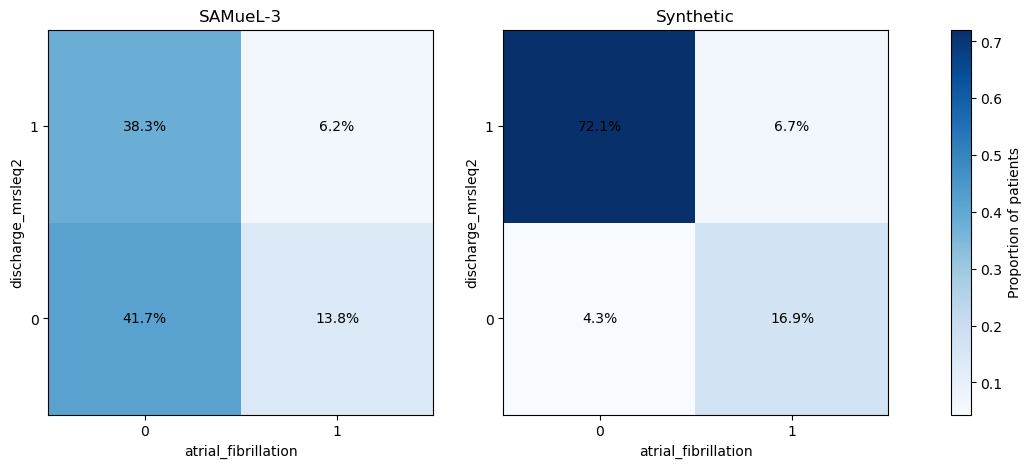

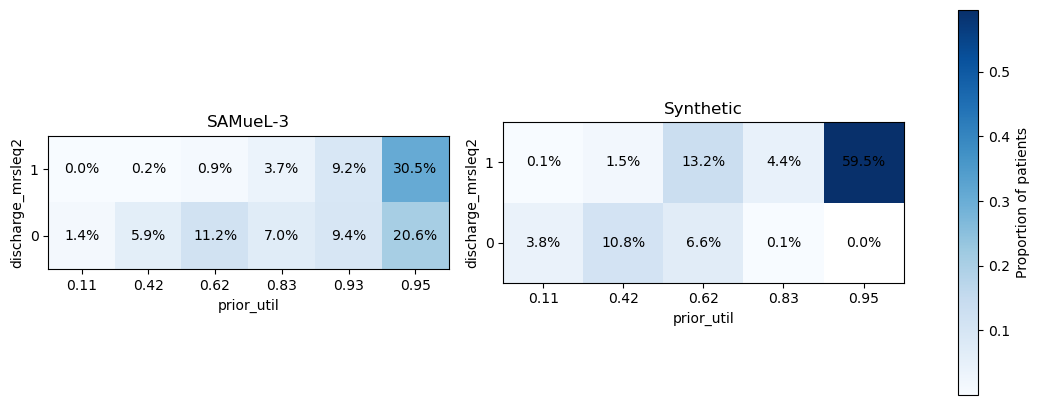

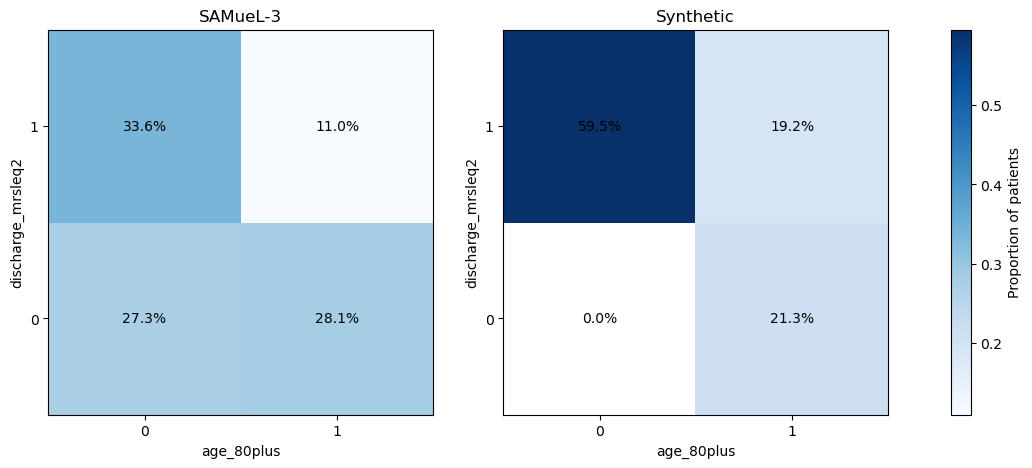

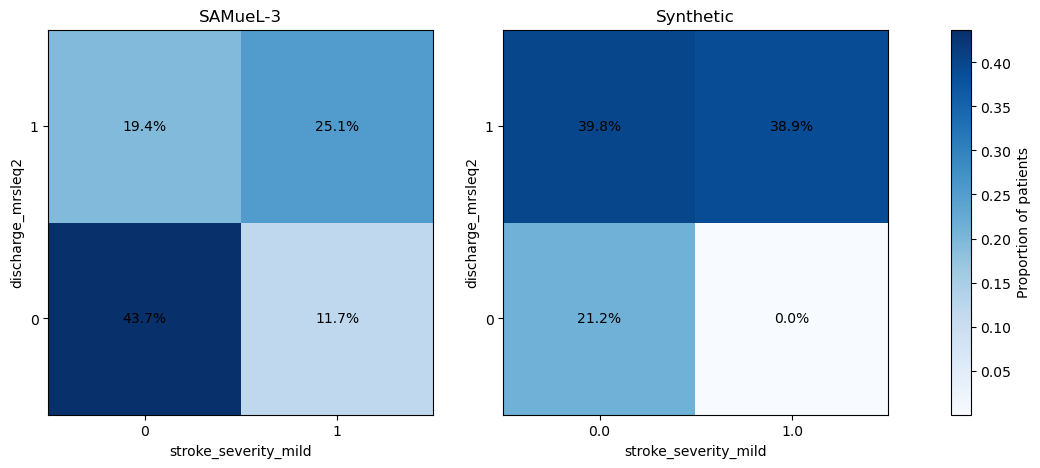

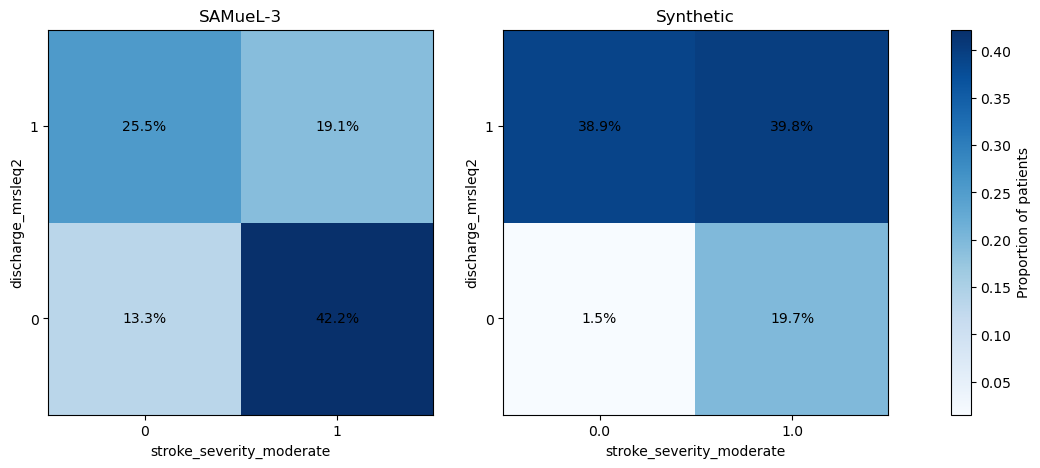

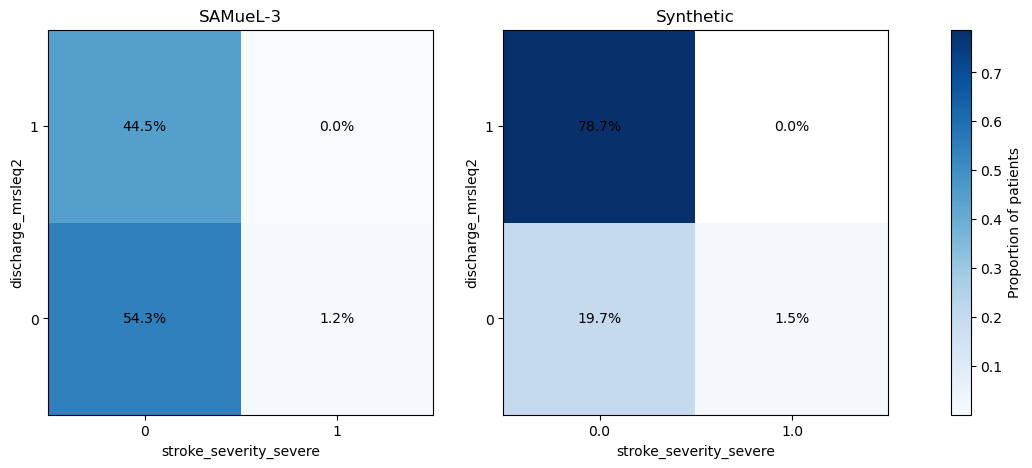

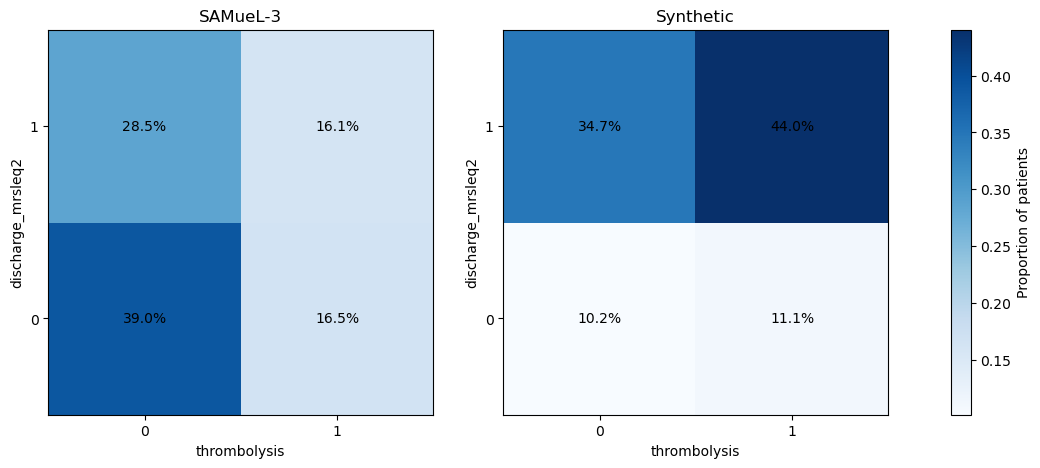

In [57]:
# For each node that is affected by another:
for child in df_effects.columns:
    # Pick out the nodes that affect this node:
    parents = df_effects[df_effects[child].notna()].index
    parents = [p for p in parents if p != 'const']
    print(f'{child}: {parents}')

    # Plot the grids of real and synthetic data.
    for parent in parents:
        if parent not in stroke_teams and child not in stroke_teams:
            savename = f'images/sam3_vs_synth/sam3_vs_synth_grid_{parent}_vs_{child}.png'
            compare_data(df, df_synth, parent, child, savename=savename)